# Determinism of the FEM backend under a pinned thread count

**REPRO-02.** `FEMPendulum` enters NGSolve's `TaskManager()` without pinning a
thread count, and repeated identical runs diverge. Bit-identical runs were
verified only under `SetNumThreads(1)`. This notebook tests whether a fixed count
above one, such as the six physical cores of this machine, is also enough.

Design:

- **Full FEM, no contact, short horizon.** The cheapest configuration that still
  exercises NGSolve's parallel assembly every macro step.
- **Bit-for-bit comparison** of `theta` and `omega`. Comparing contact or switch
  counts would pass falsely, because REPRO-02 found the early events agree even
  unpinned.
- **One process per configuration**, because `SetNumThreads` is process-global,
  plus a second process for every pinned count to check reproducibility across
  processes, not only within one.
- **Positive control.** The default thread count must show a difference. If it
  does not, the horizon is too short to expose the effect, and a pinned result
  proves nothing.


In [1]:
from pathlib import Path
import sys
import tempfile

import numpy as np
import pandas as pd
from IPython.display import display

sys.path.insert(0, str(Path.cwd().resolve()))
from evidence import repo_root

REPO = repo_root()

import evidence.determinism as det
from plot_setup import FULL_WIDTH, set_professional_style
from record import record, paper_results_dir

FIG_DIR = REPO / "notebooks" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
RESULTS, _results_source = paper_results_dir(REPO)
print(f"results     : {_results_source}")

plt = set_professional_style(latex=True)
print(f"interpreter : {sys.executable}")


results     : sibling SysSimX-Framework-Paper checkout
interpreter : c:\Users\flori\anaconda3\envs\env-paper-313\python.exe


## Configuration

`0` leaves NGSolve at its default. `1` is the only count REPRO-02 verified. `6` is
the number of physical cores of the i7-10850H this campaign runs on. The arrays
go to the system temp directory, not the repository.


In [2]:
THREAD_COUNTS = (0, 1, 6)
N_RUNS = 3            # runs inside one process
HORIZON_S = 0.4
CONTACT = False
CROSS_PROCESS = True  # one extra process per pinned count

OUT_DIR = Path(tempfile.gettempdir()) / "syssimx_determinism" / (
    f"{'contact' if CONTACT else 'nocontact'}_{HORIZON_S:g}s"
)
print(f"arrays : {OUT_DIR}")


arrays : C:\Users\flori\AppData\Local\Temp\syssimx_determinism\nocontact_0.4s


In [3]:
runs = {}
for threads in THREAD_COUNTS:
    runs[(threads, "A")] = det.run_configuration(
        threads, N_RUNS, HORIZON_S, CONTACT, OUT_DIR, "A"
    )
    if CROSS_PROCESS and threads != 0:
        runs[(threads, "B")] = det.run_configuration(
            threads, 1, HORIZON_S, CONTACT, OUT_DIR, "B"
        )


  threads=default run=0 wall=79.9s samples=400
  threads=default run=1 wall=88.0s samples=400
  threads=default run=2 wall=76.0s samples=400
  process threads=default tag=A: 247.8 s
  threads=1 run=0 wall=197.4s samples=400
  threads=1 run=1 wall=182.2s samples=400
  threads=1 run=2 wall=194.1s samples=400
  process threads=1 tag=A: 577.0 s
  threads=1 run=0 wall=222.1s samples=400
  process threads=1 tag=B: 225.1 s
  threads=6 run=0 wall=82.5s samples=400
  threads=6 run=1 wall=81.9s samples=400
  threads=6 run=2 wall=81.4s samples=400
  process threads=6 tag=A: 249.7 s
  threads=6 run=0 wall=80.6s samples=400
  process threads=6 tag=B: 83.8 s


## Comparison

Within a process, run 0 is compared against every later run. Across processes,
run 0 of process A is compared against run 0 of process B. `identical` means the
time grid and both state arrays are equal bit for bit.


In [4]:
rows = []
for threads in THREAD_COUNTS:
    first = runs[(threads, "A")][0]
    pairs = [
        (f"within, run 0 vs {k}", first, path)
        for k, path in enumerate(runs[(threads, "A")][1:], start=1)
    ]
    if (threads, "B") in runs:
        pairs.append(("across processes", first, runs[(threads, "B")][0]))
    for kind, a, b in pairs:
        c = det.compare(a, b)
        rows.append({
            "threads": "default" if threads == 0 else str(threads),
            "comparison": kind,
            "identical": c.identical,
            "same grid": c.same_grid,
            "max |dtheta| rad": c.max_abs_dtheta,
            "max |domega| rad/s": c.max_abs_domega,
            "first difference s": (np.nan if c.first_difference_t is None
                                   else c.first_difference_t),
        })

table = pd.DataFrame(rows)
display(table.style.format({
    "max |dtheta| rad": "{:.3e}",
    "max |domega| rad/s": "{:.3e}",
    "first difference s": "{:.4f}",
}).hide(axis="index"))


threads,comparison,identical,same grid,max |dtheta| rad,max |domega| rad/s,first difference s
default,"within, run 0 vs 1",False,True,1.166e-07,1.118e-05,0.0010
default,"within, run 0 vs 2",False,True,4.800e-08,1.251e-05,0.0010
1,"within, run 0 vs 1",True,True,0.000e+00,0.000e+00,nan
1,"within, run 0 vs 2",True,True,0.000e+00,0.000e+00,nan
1,across processes,True,True,0.000e+00,0.000e+00,nan
6,"within, run 0 vs 1",False,True,3.370e-07,2.249e-05,0.0010
6,"within, run 0 vs 2",False,True,2.859e-07,2.220e-05,0.0010
6,across processes,False,True,9.652e-07,2.306e-04,0.0010


In [5]:
def all_identical(label):
    return bool(table.loc[table["threads"] == label, "identical"].all())


if all_identical("default"):
    print("INCONCLUSIVE: the default thread count was also bit-identical, so this "
          "horizon does not expose REPRO-02 and a pinned result proves nothing.")
    print("Set CONTACT = True and HORIZON_S = 0.25, then run again.")
else:
    print("positive control : default threading differs between runs, so the test "
          "can see the effect")
    for threads in THREAD_COUNTS:
        if threads == 0:
            continue
        verdict = "DETERMINISTIC" if all_identical(str(threads)) else "NOT deterministic"
        print(f"threads = {threads:<2}      : {verdict}")


positive control : default threading differs between runs, so the test can see the effect
threads = 1       : DETERMINISTIC
threads = 6       : NOT deterministic


In [6]:
# Recorded as supporting evidence for the section 5 setup sentence that the
# FEM ran single-threaded. NaN becomes None so the artifact stays valid JSON.
comparisons = table.astype(object).where(table.notna(), None).to_dict("records")
record(
    "DET_threads",
    {
        "question": "bit-identical full-FEM runs at a pinned NGSolve thread count",
        "thread_counts": [int(t) for t in THREAD_COUNTS],
        "n_runs_per_process": N_RUNS,
        "cross_process": CROSS_PROCESS,
        "horizon_s": HORIZON_S,
        "contact": CONTACT,
        "positive_control_differs": not all_identical("default"),
        "deterministic": {str(t): all_identical(str(t)) for t in THREAD_COUNTS if t != 0},
        "comparisons": comparisons,
    },
    directory=RESULTS,
    notebook="06_determinism",
    smoke=False,
)


WindowsPath('C:/Users/flori/source/repos/FlorianFrech/SysSimX-Framework-Paper/results/DET_threads.json')

## How fast unpinned runs drift apart

The difference between two default-threaded runs, on a log scale. The first
non-zero sample marks where the parallel assembly first changed a bit.


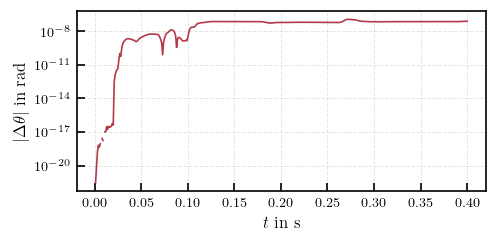

In [7]:
a, b = (np.load(p) for p in runs[(0, "A")][:2])
n = min(a["t"].size, b["t"].size)
diff = np.abs(a["theta"][:n] - b["theta"][:n])

fig, ax = plt.subplots(figsize=(0.72 * FULL_WIDTH, 0.36 * FULL_WIDTH))
if np.any(diff > 0.0):
    ax.semilogy(a["t"][:n], np.where(diff > 0.0, diff, np.nan),
                color="#B23A48", linewidth=1.0)
else:
    ax.text(0.5, 0.5, "bit-identical", transform=ax.transAxes,
            ha="center", va="center")
ax.set_xlabel(r"$t$ in $\mathrm{s}$")
ax.set_ylabel(r"$|\Delta\theta|$ in $\mathrm{rad}$")
ax.grid(True, alpha=0.4)
fig.tight_layout()
fig.savefig(FIG_DIR / "DET_threads.pdf", bbox_inches="tight")
plt.show()


## Reading the result

A pinned count that is bit-identical here is deterministic **for this
configuration and horizon**: no contact, 0.05 s. The contact path runs a
different sub-stepping loop, so before relying on the count for `03_switching`,
repeat the test with `CONTACT = True` and a horizon that includes several
contacts.

If the chosen count is deterministic, set it in `03_switching` before the plant is
built, with `NGS_NUM_THREADS` set to the same value so `record()` writes it into
the provenance. Timing in `04_performance` stays at the default.
